In [2]:
import pandas as pd
df = pd.read_csv("python-2_lab/diabetes_unclean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1009 non-null   int64  
 1   No_Pation  1009 non-null   int64  
 2   Gender     1009 non-null   object 
 3   AGE        1008 non-null   float64
 4   Urea       1008 non-null   float64
 5   Cr         1007 non-null   float64
 6   HbA1c      1006 non-null   float64
 7   Chol       1007 non-null   float64
 8   TG         1007 non-null   float64
 9   HDL        1008 non-null   float64
 10  LDL        1007 non-null   float64
 11  VLDL       1008 non-null   float64
 12  BMI        1009 non-null   float64
 13  CLASS      1009 non-null   object 
dtypes: float64(10), int64(2), object(2)
memory usage: 110.5+ KB


In [3]:
df.sample()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
509,295,39576,F,56.0,3.8,42.0,9.0,4.0,5.1,1.75,0.96,2.2,26.0,Y


In [4]:
df.isna().sum()

ID           0
No_Pation    0
Gender       0
AGE          1
Urea         1
Cr           2
HbA1c        3
Chol         2
TG           2
HDL          1
LDL          2
VLDL         1
BMI          0
CLASS        0
dtype: int64

In [5]:
df.isnull().sum()

ID           0
No_Pation    0
Gender       0
AGE          1
Urea         1
Cr           2
HbA1c        3
Chol         2
TG           2
HDL          1
LDL          2
VLDL         1
BMI          0
CLASS        0
dtype: int64

In [6]:
# find out the shape or csv
df.shape

(1009, 14)

In [27]:
# replace the missing values in the column HbA1c with their mean value
df['HbA1c'] = df['HbA1c'].fillna(df['HbA1c'].mean())

# Check missing values
df.isna().sum()

ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

In [8]:
mean_hba1c = df['HbA1c'].mean()
df['HbA1c'] = df['HbA1c'].fillna(mean_hba1c)
df.isna().sum()


ID           0
No_Pation    0
Gender       0
AGE          1
Urea         1
Cr           2
HbA1c        0
Chol         2
TG           2
HDL          1
LDL          2
VLDL         1
BMI          0
CLASS        0
dtype: int64

In [9]:
#Describe the obj column , display the statstical obj column
import numpy as np
df.describe(include=np.object_)

,Gender,CLASS
count,1009,1009
unique,3,5
top,M,Y
freq,570,840


In [10]:
# drop the missing col value of other col 
df.dropna(inplace = True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 997 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         997 non-null    int64  
 1   No_Pation  997 non-null    int64  
 2   Gender     997 non-null    object 
 3   AGE        997 non-null    float64
 4   Urea       997 non-null    float64
 5   Cr         997 non-null    float64
 6   HbA1c      997 non-null    float64
 7   Chol       997 non-null    float64
 8   TG         997 non-null    float64
 9   HDL        997 non-null    float64
 10  LDL        997 non-null    float64
 11  VLDL       997 non-null    float64
 12  BMI        997 non-null    float64
 13  CLASS      997 non-null    object 
dtypes: float64(10), int64(2), object(2)
memory usage: 116.8+ KB


In [12]:
# display the corelation btw variables
df.corr

<bound method DataFrame.corr of        ID  No_Pation Gender   AGE  Urea     Cr      HbA1c  Chol   TG  HDL  \
0     502      17975      F  50.0   4.7   46.0   4.900000   4.2  0.9  2.4   
1     735      34221      M  26.0   4.5   62.0   4.900000   3.7  1.4  1.1   
2     420      47975      F  50.0   4.7   46.0   4.900000   4.2  0.9  2.4   
3     680      87656      F  50.0   4.7   46.0   4.900000   4.2  0.9  2.4   
4     504      34223      M  33.0   7.1   46.0   4.900000   4.9  1.0  0.8   
...   ...        ...    ...   ...   ...    ...        ...   ...  ...  ...   
1002  188     454316      F  75.0  10.3  113.0   8.600000   4.2  1.6  0.9   
1003  189     454316      M  58.0   4.0   55.0   7.900000   4.9  2.0  1.2   
1005  192     454316      M  55.0   4.8   88.0   8.284155   5.7  4.0  0.9   
1007  194     454316      F  57.0   4.1   70.0   9.300000   5.3  3.3  1.0   
1008  195       4543      f  55.0   4.1   34.0  13.900000   5.4  1.6  1.6   

      LDL  VLDL   BMI CLASS  
0     1.4   0

# visualize 'Urea','HbA1c ','TG' & 'BMI' for diff.ages using parallel coordinates with label and title - IMP

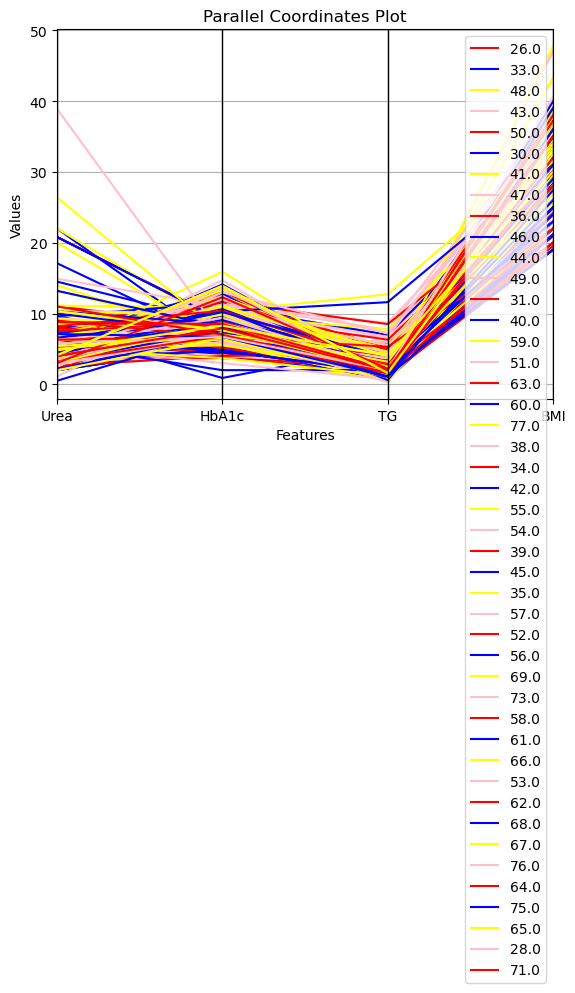

In [28]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt

parallel_coordinates(df, 'AGE', cols=['Urea', 'HbA1c', 'TG', 'BMI'], 
                     color=['red', 'blue', 'yellow', 'pink'])

plt.title("Parallel Coordinates Plot")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [26]:
# Count frequency of M and F
print(df['Gender'].value_counts())

# Remove rows where Gender is F
df = df[df['Gender'] != 'F']

# (Optional) check remaining data
print("\nAfter removing F:")
print(df['Gender'].value_counts())

Gender
M    563
f      2
Name: count, dtype: int64

After removing F:
Gender
M    563
f      2
Name: count, dtype: int64


# Finding and Removing Outliers

In [5]:
import pandas as pd
def find_outliers(ds,col):
    qua1 = ds[col].quantile(0.25)
    qua2 = ds[col].quantile(0.75)
    IQR = qua2 - qua1
    low_val = qua1-(1.5 * IQR)
    high_val = qua2 +(1.5*IQR)
    ds = ds.loc[(ds[col]<low_val) | (ds[col]>high_val)]
    print(low_val,high_val)
    return ds
df = pd.read_csv('python-2_lab/diabetes_unclean.csv')
find_outliers(df,'HbA1c')
    

0.9500000000000011 15.749999999999998


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
80,138,45399,F,57.0,4.6,97.0,0.9,3.2,1.3,0.9,3.0,1.1,22.0,N
92,161,45406,F,60.0,7.5,70.0,0.9,3.4,5.3,1.1,3.6,0.8,24.0,N
98,182,454316,M,60.0,7.5,70.0,0.9,3.4,5.3,1.1,3.6,0.8,24.0,N
101,197,454316,F,57.0,4.6,97.0,0.9,3.2,1.3,0.9,3.0,1.1,22.0,N
805,689,34554,M,55.0,5.1,39.0,15.9,4.2,1.2,1.4,3.0,2.0,38.0,Y
897,61,65456,F,61.0,8.1,72.0,16.0,7.7,3.1,1.6,4.9,1.4,26.0,Y


In [9]:
# remove the ouliers from the col HbA1c
import pandas as pd
def find_outliers(ds,col):
    qua1 = ds[col].quantile(0.25)
    qua2 = ds[col].quantile(0.75)
    IQR = qua2 - qua1
    low_val = qua1-(1.5 * IQR)
    high_val = qua2 +(1.5*IQR)
    ds = ds.loc[(ds[col]>=low_val) & (ds[col]<=high_val)]
    print(low_val , high_val)
    return ds
df = pd.read_csv('python-2_lab/diabetes_unclean.csv')
find_outliers(df,'HbA1c')
    

0.9500000000000011 15.749999999999998


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,189,454316,M,58.0,4.0,55.0,7.9,4.9,2.0,1.2,1.4,1.1,35.0,Y
1004,191,454316,M,55.0,NaN,62.0,6.8,5.3,2.0,1.0,3.5,0.9,30.1,Y
1006,193,454316,M,62.0,6.3,82.0,6.7,5.3,2.0,1.0,3.5,NaN,30.1,Y
1007,194,454316,F,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y


# check the outliers in the dataset for HbA1c col with a using box plot with the title & labels

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1009 non-null   int64  
 1   No_Pation  1009 non-null   int64  
 2   Gender     1009 non-null   object 
 3   AGE        1008 non-null   float64
 4   Urea       1008 non-null   float64
 5   Cr         1007 non-null   float64
 6   HbA1c      1006 non-null   float64
 7   Chol       1007 non-null   float64
 8   TG         1007 non-null   float64
 9   HDL        1008 non-null   float64
 10  LDL        1007 non-null   float64
 11  VLDL       1008 non-null   float64
 12  BMI        1009 non-null   float64
 13  CLASS      1009 non-null   object 
dtypes: float64(10), int64(2), object(2)
memory usage: 110.5+ KB


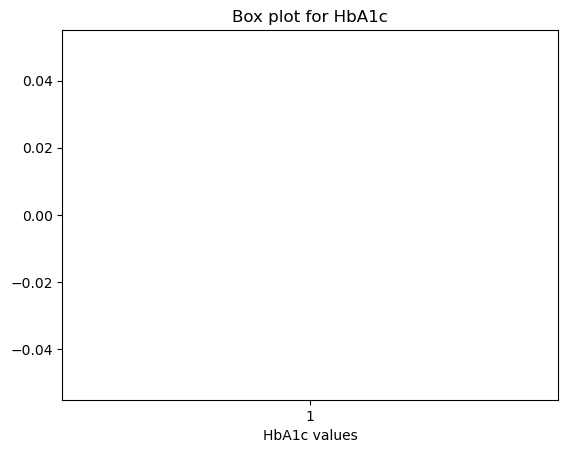

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("python-2_lab/diabetes_unclean.csv")

df.info()

# Correct boxplot
plt.boxplot(df['HbA1c'], widths=0.75, notch=True)

plt.title("Box plot for HbA1c")
plt.xlabel("HbA1c values")

plt.show()

In [22]:
# data Agriation and transformation


In [27]:
import pandas as pd
data = {'Department' :['IT','HR','IT','HR','FINANCE'],
         'Employee':['A','B','C','D','E'] ,
         'salary':[50000,40000,60000,45000,70000],
         'ID':[23,10,40,80,5]}
df = pd.DataFrame(data)

In [28]:
df

,Department,Employee,salary,ID
0,IT,A,50000,23
1,HR,B,40000,10
2,IT,C,60000,40
3,HR,D,45000,80
4,FINANCE,E,70000,5


In [30]:
result = df.groupby('Department')
print(result)

In [35]:
for i in result:
    print(i)
    print("-----------------------------------------------")

('FINANCE',   Department Employee  salary  ID
4    FINANCE        E   70000   5)
-----------------------------------------------
('HR',   Department Employee  salary  ID
1         HR        B   40000  10
3         HR        D   45000  80)
-----------------------------------------------
('IT',   Department Employee  salary  ID
0         IT        A   50000  23
2         IT        C   60000  40)
-----------------------------------------------


In [36]:
result1 = df.groupby('Department').sum()
print(result1)

           Employee  salary  ID
Department                     
FINANCE           E   70000   5
HR               BD   85000  90
IT               AC  110000  63


In [37]:
result1 = df.groupby('Department',as_index=False,sort=False).sum()
print(result1)

  Department Employee  salary  ID
0         IT       AC  110000  63
1         HR       BD   85000  90
2    FINANCE        E   70000   5


In [41]:
result1 = df.groupby('Department', as_index=False, sort=False).mean(numeric_only=True)
print(result1)

  Department   salary    ID
0         IT  55000.0  31.5
1         HR  42500.0  45.0
2    FINANCE  70000.0   5.0


In [42]:
result1 = df.groupby('Department', as_index=False, sort=False).median(numeric_only=True)
print(result1)

  Department   salary    ID
0         IT  55000.0  31.5
1         HR  42500.0  45.0
2    FINANCE  70000.0   5.0


In [43]:
result1 = df.groupby('Department', as_index=False, sort=False).max(numeric_only=True)
print(result1)

  Department  salary  ID
0         IT   60000  40
1         HR   45000  80
2    FINANCE   70000   5


In [44]:
result1 = df.groupby('Department', as_index=False, sort=False).min(numeric_only=True)
print(result1)

  Department  salary  ID
0         IT   50000  23
1         HR   40000  10
2    FINANCE   70000   5


In [45]:
df.groupby('Department')['salary'].agg(['sum','mean','max'])

,sum,mean,max
Department,,,
FINANCE,70000,70000.0,70000
HR,85000,42500.0,45000
IT,110000,55000.0,60000


In [54]:
df.groupby('Department')[['salary','ID']].agg(['sum','mean','max'])

salary                  ID          
               sum     mean    max sum  mean max
Department                                      
FINANCE      70000  70000.0  70000   5   5.0   5
HR           85000  42500.0  45000  90  45.0  80
IT          110000  55000.0  60000  63  31.5  40

In [55]:
df.groupby('Department').count()

,Employee,salary,ID
Department,,,
FINANCE,1,1,1
HR,2,2,2
IT,2,2,2


In [56]:
df.groupby('Department').nunique()

,Employee,salary,ID
Department,,,
FINANCE,1,1,1
HR,2,2,2
IT,2,2,2


In [57]:
df.groupby('Department').size()

Department
FINANCE    1
HR         2
IT         2
dtype: int64

In [58]:
df.groupby('Department').describe()

salary                                                            \
            count     mean          std      min      25%      50%      75%   
Department                                                                    
FINANCE       1.0  70000.0          NaN  70000.0  70000.0  70000.0  70000.0   
HR            2.0  42500.0  3535.533906  40000.0  41250.0  42500.0  43750.0   
IT            2.0  55000.0  7071.067812  50000.0  52500.0  55000.0  57500.0   

                       ID                                                   
                max count  mean        std   min    25%   50%    75%   max  
Department                                                                  
FINANCE     70000.0   1.0   5.0        NaN   5.0   5.00   5.0   5.00   5.0  
HR          45000.0   2.0  45.0  49.497475  10.0  27.50  45.0  62.50  80.0  
IT          60000.0   2.0  31.5  12.020815  23.0  27.25  31.5  35.75  40.0

In [62]:
df.groupby('Department').nth(0)

,Department,Employee,salary,ID
0,IT,A,50000,23
1,HR,B,40000,10
4,FINANCE,E,70000,5


In [63]:
df.groupby('Department').nth(1)

,Department,Employee,salary,ID
2,IT,C,60000,40
3,HR,D,45000,80


In [64]:
df.groupby('Department').nth(3)

,Department,Employee,salary,ID


In [65]:
# Apply Function 

In [68]:
import pandas as pd
df1 = pd.DataFrame({
                    "maths":[80,85,90],
                    "Science":[78,82,88],
                    "English":[70,75,80]
                    })
print(df1)
print("----------------------------")
result = df1.apply(sum)
print(result)

   maths  Science  English
0     80       78       70
1     85       82       75
2     90       88       80
----------------------------
maths      255
Science    248
English    225
dtype: int64


In [72]:
import pandas as pd
df1 = pd.DataFrame({
                    "maths":[80,85,90],
                    "Science":[78,82,88],
                    "English":[70,75,80]
                    })
print(df1)
print("----------------------------")
result = df1.apply(lambda x:x.mean())
print(result)

   maths  Science  English
0     80       78       70
1     85       82       75
2     90       88       80
----------------------------
maths      85.000000
Science    82.666667
English    75.000000
dtype: float64


In [76]:
import pandas as pd

df1 = pd.DataFrame({
    "maths":[80,85,90],
    "Science":[78,82,88],
    "English":[70,75,80]
})

print(df1)
print("----------------------------")

result = df1.apply(lambda x: x.mean())
print(result)

def grade(total):
    if total >= 250:
        return "A"
    elif total >= 200:
        return "B"
    else:
        return "C"

df1["total"] = df1.apply(lambda x: x.sum(), axis=1)

df1['grade'] = df1["total"].apply(grade)

print(df1)

   maths  Science  English
0     80       78       70
1     85       82       75
2     90       88       80
----------------------------
maths      85.000000
Science    82.666667
English    75.000000
dtype: float64
   maths  Science  English  total grade
0     80       78       70    228     B
1     85       82       75    242     B
2     90       88       80    258     A


In [78]:
df = pd.DataFrame({
    "A":[1,2,3],
    "B":[4,5,6],
    "C":[7,8,9]
})

result = df.apply(sum,axis=1,raw=True)
print(result)

0    12
1    15
2    18
dtype: int64


In [79]:
df = pd.DataFrame({
    "X":[10,20,30],
    "Y":[15,25,35],
    "Z":[20,30,40]
})
result = df.apply(lambda x:[x.sum(),x.mean()],axis=1,result_type="expand")
print(result)

       0     1
0   45.0  15.0
1   75.0  25.0
2  105.0  35.0


In [84]:
df = pd.DataFrame({
    "X":[10,20,30],
    "Y":[15,25,35],
    "Z":[20,30,40]
})
result1 = df.apply(lambda x: x-x.mean(),result_type="broadcast")
print(result1)

    X   Y   Z
0 -10 -10 -10
1   0   0   0
2  10  10  10


In [86]:
df = pd.DataFrame({
    "X":[10,20,30],
    "Y":[15,25,35],
    "Z":[20,30,40]
})

def add_bonus(x,bonus):
    return x+bonus
result= df.apply(add_bonus,axis=1,args=(5,))
print(result)


    X   Y   Z
0  15  20  25
1  25  30  35
2  35  40  45


In [88]:
df = pd.DataFrame({
    "X":[10,20,30],
    "Y":[15,25,35],
    "Z":[20,30,40]
})

def add_bonus(x,bonus,bonus1):
    return x+bonus+bonus1
result= df.apply(add_bonus,axis=1,args=(5,10))
print(result)


    X   Y   Z
0  25  30  35
1  35  40  45
2  45  50  55


In [2]:
 # astype() - to change the data type

In [4]:
import pandas as pd
data = {'Age':['25','30','35'],
       'weight':['50.5','65.5','66.0']
       }
df = pd.DataFrame(data)
print(df.dtypes)
print(df)

Age       object
weight    object
dtype: object
  Age weight
0  25   50.5
1  30   65.5
2  35   66.0


In [8]:
df['Age'] = df['Age'].astype(int)
print(df.dtypes)
print(df)

Age        int64
weight    object
dtype: object
   Age weight
0   25   50.5
1   30   65.5
2   35   66.0


In [13]:
df['weight'] = df['weight'].astype(int)
print(df.dtypes)
print(df)

Age       float64
weight      int64
dtype: object
    Age  weight
0  25.0      50
1  30.0      65
2  35.0      66


In [14]:
import pandas as pd
data = {'Age':['25','30','35'],
       'weight':['50.5','65.5','66.0']
       }
df = df.astype({'Age':int,'weight':float})
print(df.dtypes)



Age         int64
weight    float64
dtype: object


In [15]:
# replace() 
result = df.replace(25,30)
print(result)

   Age  weight
0   30    50.0
1   30    65.0
2   35    66.0


In [18]:
result = df.replace({25:30,30:35})
print(result)

   Age  weight
0   30    50.0
1   35    65.0
2   35    66.0


In [19]:
df = pd.DataFrame({
    'Name':['A','B','C'],
    'Score':[25,10,30]
})
print(df)
result = df.replace(['A',25],['D',100])
print(result)

  Name  Score
0    A     25
1    B     10
2    C     30
  Name  Score
0    D    100
1    B     10
2    C     30


# merge()
 - combine (join) to Dm 

In [23]:
#merge() function
df1=pd.DataFrame({'ID':[1,2,3],'Name':['A','B','C']})
df2=pd.DataFrame({'ID':[2,3,4],'Salary':[20000,30000,40000]})
print(df1)
print('---------------------------')
print(df2)
print('---------------------------')

result=pd.merge(df1,df2,on='ID',how='outer')
print(result)

   ID Name
0   1    A
1   2    B
2   3    C
---------------------------
   ID  Salary
0   2   20000
1   3   30000
2   4   40000
---------------------------
   ID Name   Salary
0   1    A      NaN
1   2    B  20000.0
2   3    C  30000.0
3   4  NaN  40000.0


In [24]:
#merge() function
df1=pd.DataFrame({'ID':[1,2,3],'Name':['A','B','C']})
df2=pd.DataFrame({'ID':[2,3,4],'Salary':[20000,30000,40000]})
print(df1)
print('---------------------------')
print(df2)
print('---------------------------')

result=pd.merge(df1,df2,on='ID',how='left')
print(result)

   ID Name
0   1    A
1   2    B
2   3    C
---------------------------
   ID  Salary
0   2   20000
1   3   30000
2   4   40000
---------------------------
   ID Name   Salary
0   1    A      NaN
1   2    B  20000.0
2   3    C  30000.0


In [25]:
#merge() function
df1=pd.DataFrame({'ID':[1,2,3],'Name':['A','B','C']})
df2=pd.DataFrame({'ID':[2,3,4],'Salary':[20000,30000,40000]})
print(df1)
print('---------------------------')
print(df2)
print('---------------------------')

result=pd.merge(df1,df2,on='ID',how='right')
print(result)

   ID Name
0   1    A
1   2    B
2   3    C
---------------------------
   ID  Salary
0   2   20000
1   3   30000
2   4   40000
---------------------------
   ID Name  Salary
0   2    B   20000
1   3    C   30000
2   4  NaN   40000


In [38]:
#merge() function
df1=pd.DataFrame({'emp_ID':[1,2,3],'Name':['A','B','C']})
df2=pd.DataFrame({'ID':[2,3,4],'Salary':[20000,30000,40000]})
print(df1)
print('---------------------------')
print(df2)
print('---------------------------')
result = pd.merge(df1,df2,left_on='emp_ID',right_on='ID')
print(result)
# result=pd.merge(df1,df2,on='emp_ID',how='left')
# print(result)

   emp_ID Name
0       1    A
1       2    B
2       3    C
---------------------------
   ID  Salary
0   2   20000
1   3   30000
2   4   40000
---------------------------
   emp_ID Name  ID  Salary
0       2    B   2   20000
1       3    C   3   30000


In [39]:
df1 = pd.DataFrame({'ID':[1,2,3],
                   'Name':["A","B","C"],
                   'Salary':[2000,3000,4000]})
df2 = pd.DataFrame({'ID':[2,3,4],
                   'Name':["A","B","C"],
                   'Salary':[2000,3000,4000]})
result = pd.merge(df1,df2,on='ID',suffixes=('_x','_y'),how='inner')
print(result)

   ID Name_x  Salary_x Name_y  Salary_y
0   2      B      3000      A      2000
1   3      C      4000      B      3000


In [43]:
#concat()
import pandas as pd
df1=pd.DataFrame({'A':[1,2]})
df2=pd.DataFrame({'B':[3,4]})
# Fix: pd.concat() expects a list of DataFrames as first argument
result=pd.concat([df1,df2],axis=1)  # Put DataFrames in a list
print(result)

   A  B
0  1  3
1  2  4


In [45]:
#concat()
import pandas as pd
df1=pd.DataFrame({'A':[1,2]})
df2=pd.DataFrame({'B':[3,4]})
# Fix: pd.concat() expects a list of DataFrames as first argument
result=pd.concat([df1,df2],join='inner')  # Put DataFrames in a list
print(result)

Empty DataFrame
Columns: []
Index: [0, 1, 0, 1]


In [50]:
#concat()
import pandas as pd
df1=pd.DataFrame({'A':[1,2]})
df2=pd.DataFrame({'A':[3,4]})
# Fix: pd.concat() expects a list of DataFrames as first argument
result=pd.concat([df1,df2],axis=0,ignore_index=True)  # Put DataFrames in a list
print(result)

   A
0  1
1  2
2  3
3  4


In [52]:
df1=pd.DataFrame({'A':[9,10],
                 'B':[3,4]})
df2=pd.DataFrame({'C':[5,6],
                 'D':[7,8]})
pd.concat([df1,df2],sort=True)

,A,B,C,D
0,9.0,3.0,NaN,NaN
1,10.0,4.0,NaN,NaN
0,NaN,NaN,5.0,7.0
1,NaN,NaN,6.0,8.0


In [53]:
df1=pd.DataFrame({'E':[9,10],
                 'B':[3,4]})
df2=pd.DataFrame({'C':[5,6],
                 'D':[7,8]})
pd.concat([df1,df2],sort=True)

,B,C,D,E
0,3.0,NaN,NaN,9.0
1,4.0,NaN,NaN,10.0
0,NaN,5.0,7.0,NaN
1,NaN,6.0,8.0,NaN


# Unit - 2

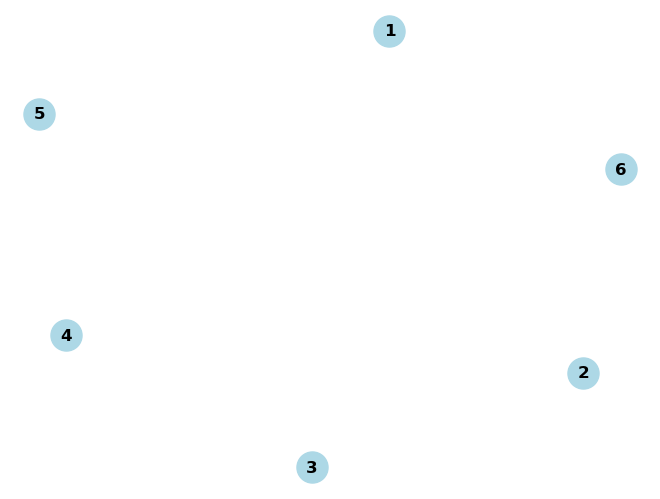

In [58]:
#Data Visualization using networkx
import networkx as nx
import matplotlib.pyplot as plt 

# Create an empty graph
G = nx.Graph()

# Add nodes to the graph
G.add_node(1)
G.add_nodes_from([2,3])
G.add_nodes_from(range(4,7))

# Draw the graph
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, font_weight='bold')

# Display the graph
plt.show()

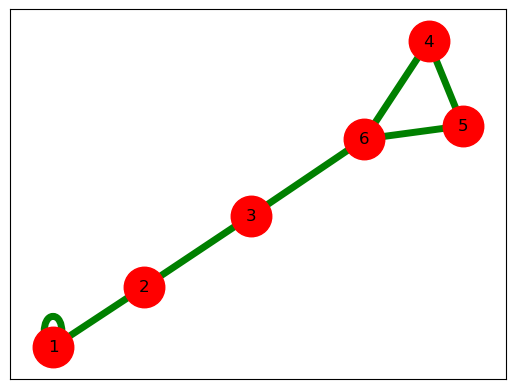

In [61]:
G.add_edge(1,2)
G.add_edge(1,1)
G.add_edges_from([(2,3),(3,6),(4,6),(5,6),(5,4)])  # Fixed typo: changed 'add_egdes_from' to 'add_edges_from'
nx.draw_networkx(G,node_size=850,node_color='red',width=5,edge_color='green')
plt.show()

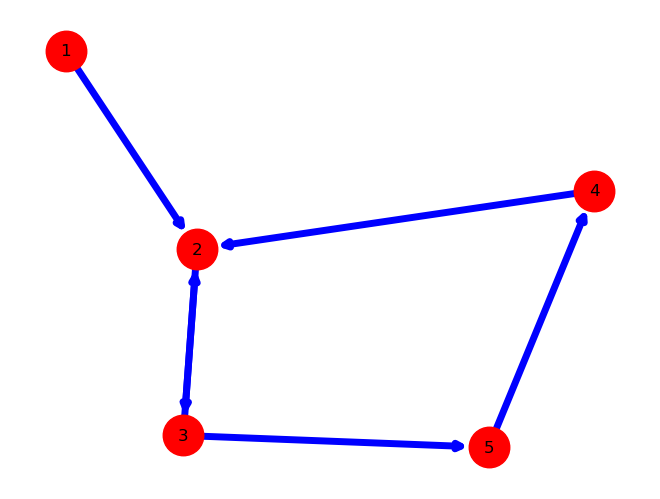

In [64]:
#Directed Graph
g=nx.DiGraph()
g.add_nodes_from([1,2,3,4,5])
g.add_edge(1,2)
g.add_edge(4,2)
g.add_edges_from([(3,5),(2,3),(5,4),(3,2)])
nx.draw(g,with_labels=True,node_size=850,node_color='red',width=5,edge_color='blue')
plt.draw()
plt.show()

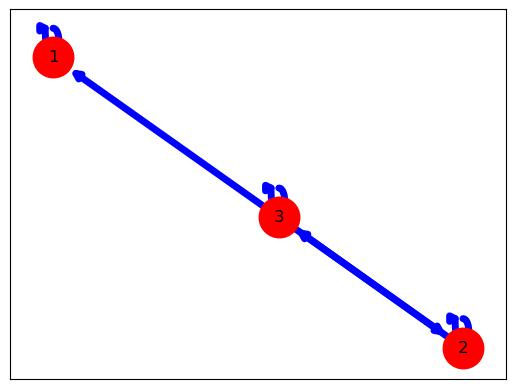

In [67]:
import networkx as nx
import matplotlib.pyplot as plt

g=nx.DiGraph()
L=[[1,0,0,1,0,1,4],[0,1,1,1,1,1,0],[1,1,1,0,1,0]]
g.add_nodes_from([1,2,3])

for i in range(0,3):
    for j in range(0,3):
        if L[i][j]==1:
            g.add_edge(i+1,j+1)
nx.draw_networkx(g,node_size=850,node_color='red',width=5,edge_color='blue')
plt.show()

In [1]:
# Unit - 3

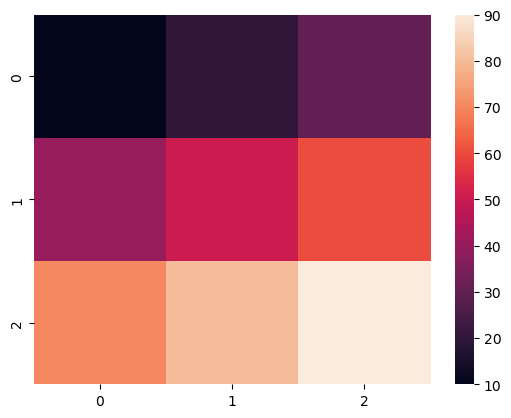

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = np.array([[10, 20, 30],
                 [40, 50, 60],
                 [70, 80, 90]])

sns.heatmap(data)

plt.show()

In [3]:
# # Heat Map

# ''' A heat map is a data visualization technique that represents values using colors.
# Instead of reading numbers, you understand patterns visually through color intensity. 

# - It’s widely used in:

# - Data analysis
# - Correlation matrices
# - Website click tracking
# - Machine learning insights

# - Why Use Heat Maps?

# - Heat maps help you:

# - Quickly identify patterns
# - Spot trends and anomalies
# - Understand relationships between variables
# - Replace large tables of numbers with visual insight

# - Libraries Used in Python

# - To create heat maps, we mainly use:

# - NumPy → for numerical data
# - Pandas → for handling datasets
# - Matplotlib → basic plotting
# - Seaborn → advanced and beautiful heatmaps
# '''

<function matplotlib.pyplot.show(close=None, block=None)>

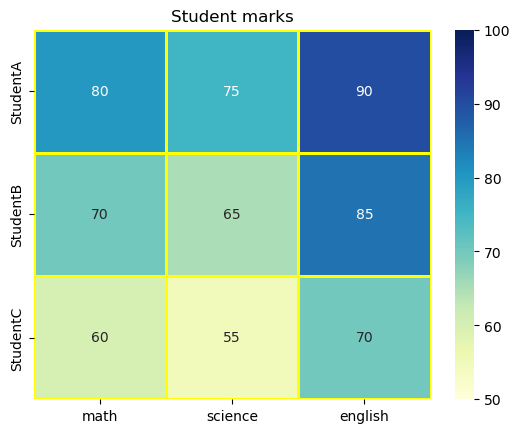

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data={"math":[80,70,60],
     "science":[75,65,55],
     "english":[90,85,70]}
df=pd.DataFrame(data,index=['StudentA',
                           'StudentB',
                           'StudentC'])
sns.heatmap(df,vmin=50,vmax=100,cmap='YlGnBu',linewidth=1,linecolor='yellow',annot=True,cbar=True)
plt.title("Student marks")
plt.show


In [7]:
# # box plot
# boxplot
# A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum. In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.

# sns.boxplot(x, y, hue, data,color)

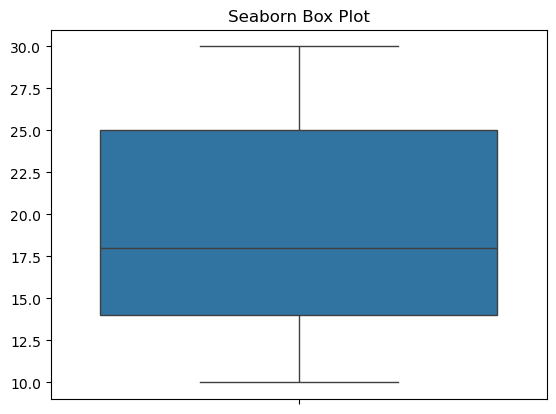

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
data = [12, 15, 14, 10, 18, 22, 25, 30, 28]

# Create box plot
sns.boxplot(data=data)

plt.title("Seaborn Box Plot")
plt.show()

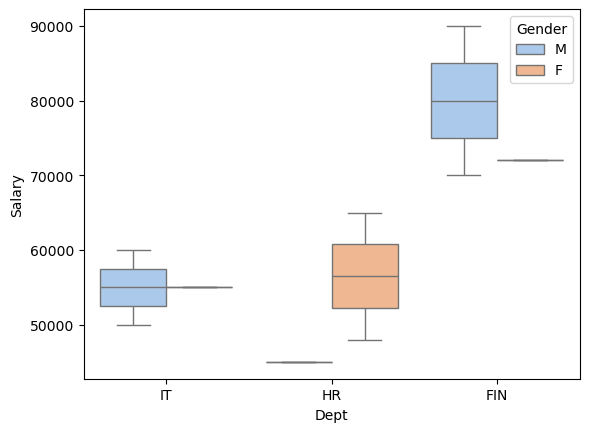

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Dept": ['IT','IT','IT','HR','HR','HR','FIN','FIN','FIN'],
    "Gender": ['M','F','M','F','M','F','M','F','M'],
    "Salary": [50000,55000,60000,65000,45000,48000,70000,72000,90000]
}

df = pd.DataFrame(data)

sns.boxplot(x='Dept', y='Salary', hue='Gender', data=df, palette='pastel')

plt.show()


In [19]:
# scatter plot

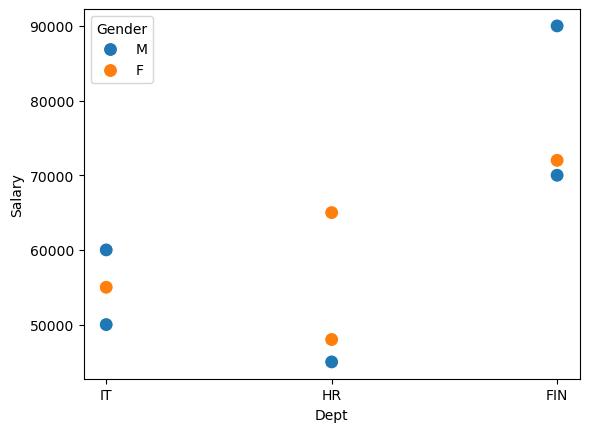

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Dept": ['IT','IT','IT','HR','HR','HR','FIN','FIN','FIN'],
    "Gender": ['M','F','M','F','M','F','M','F','M'],
    "Salary": [50000,55000,60000,65000,45000,48000,70000,72000,90000]
}

df = pd.DataFrame(data)

sns.scatterplot(x='Dept', y='Salary', hue='Gender' , s=102 ,data=df)

plt.show()

In [25]:
# Plotly
# import plotly.express as px import plotly.io as pio pio.renderers.default = "notebook"

# # If you are switching from Seaborn to Plotly, you can achieve the same "hue, style, s" logic using Plotly Express (px). The main difference is that Plotly creates interactive plots (zoom, hover, filter) rather than static images

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"
# zoom , hover,filter
# Bar chart 
data = {
    "Dept": ['IT','IT','IT','HR','HR','HR','FIN','FIN','FIN'],
    "Gender": ['M','F','M','F','M','F','M','F','M'],
    "Salary": [50000,55000,60000,65000,45000,48000,70000,72000,90000]
}
df = pd.DataFrame(data)
fig = px.bar(df,x = 'Dept',y = 'Salary' ,title="DeptSalary")
fig.show()

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"
# zoom , hover,filter
# Bar chart 
data = {
    "Dept": ['IT','IT','IT','HR','HR','HR','FIN','FIN','FIN'],
    "Gender": ['M','F','M','F','M','F','M','F','M'],
    "Salary": [50000,55000,60000,65000,45000,48000,70000,72000,90000]
}
df = pd.DataFrame(data)
fig = px.bar(df,x = 'Dept',y = 'Salary'  ,color='Gender',barmode="group",title="salary by dept & gender")
fig.update_layout(title="group")
fig.show()

In [6]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"
# zoom , hover,filter
# Bar chart 
data = {
    "Dept": ['IT','IT','IT','HR','HR','HR','FIN','FIN','FIN'],
    "Gender": ['M','F','M','F','M','F','M','F','M'],
    "Salary": [50000,55000,60000,65000,45000,48000,70000,72000,90000]
}
df = pd.DataFrame(data)
fig = px.bar(df,x = 'Dept',y = 'Salary'  ,color='Gender',barmode="stack",title="salary by dept & gender")
fig.update_layout(title="stack")
fig.show()

In [15]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

data = {
    "Dept": ['IT','IT','IT','HR','HR','HR','FIN','FIN','FIN'],
    "Gender": ['M','F','M','F','M','F','M','F','M'],
    "Salary": [50000,55000,60000,65000,45000,48000,70000,72000,90000],
    "Experience": [3, 4, 2, 3, 5, 6, 8, 1, 10]
}
df = pd.DataFrame(data)
fig = px.bar(df, x = 'Dept', y = 'Salary', color="Gender", barmode="group", title="Dept.Salary", width=800, height=500, hover_data=['Experience'], pattern_shape="Gender", text_auto=True, orientation='v', color_discrete_map={'M': 'blue', 'F': 'pink'}, color_discrete_sequence=['blue', 'pink']) # barmode = relative, stack, group
fig.show()

In [27]:
import plotly.express as px
import pandas as pd

# Sample dataset
df = pd.DataFrame({
    'Hours_Studied': [1, 2, 3, 4, 5, 6],
    'Marks': [35, 40, 50, 60, 65, 70],
    'Gender': ['M', 'F', 'M', 'F', 'M', 'F'],
    # Added Attendance column since it was referenced but missing
    'Attendance': [80, 85, 90, 75, 95, 88]
})

# 3D Scatter plot - changed from px.scatter to px.scatter_3d
fig = px.scatter_3d(
    df,
    x='Hours_Studied',
    y='Marks',
    z='Attendance',  # Now this parameter is valid
    color='Gender',
    title="3D Scatter plot",
    size='Marks',
    symbol='Gender'
)

fig.show()

In [29]:
import plotly.express as px
import pandas as pd

# Sample dataset
df = pd.DataFrame({
    'Hours_Studied': [1, 2, 3, 4, 5, 6],
    'Marks': [35, 40, 50, 60, 65, 70],
    'Gender': ['M', 'F', 'M', 'F', 'M', 'F'],
    'Attendance': [80, 85, 90, 75, 95, 88]
})

# Correct usage of scatter_matrix with data_frame parameter
fig = px.scatter_matrix(
    data_frame=df,  # Added the data_frame parameter
    dimensions=['Hours_Studied', 'Marks', 'Attendance'],
    color='Marks',
    title="Scatter matrix"
)

fig.show()

In [37]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    'Hours': [1, 2, 3, 4, 5, 6],
    'Marks': [35, 40, 50, 60, 65, 70],
    'Gender': ['M', 'F', 'M', 'F', 'M', 'F'],
    'Attendance': [80, 85, 90, 75, 95, 88],
    'Department': ['IT', 'IT', 'HR', 'HR', 'FIN', 'FIN']
})

fig = px.scatter(
    df,
    x='Hours',
    y='Marks',
    color='Gender',
    size='Attendance',
    # Removed duplicate facet_col parameter
    title="Student Performance",
    width=900,
    height=500,
    color_discrete_map={'M': 'blue', 'F': 'pink'},
    # Removed color_discrete_sequence as it conflicts with color_discrete_map
    symbol='Gender',
    facet_col='Department',  # Keep only one instance of facet_col
    facet_row='Gender'
)

fig.show()
# Removed duplicate fig.show()

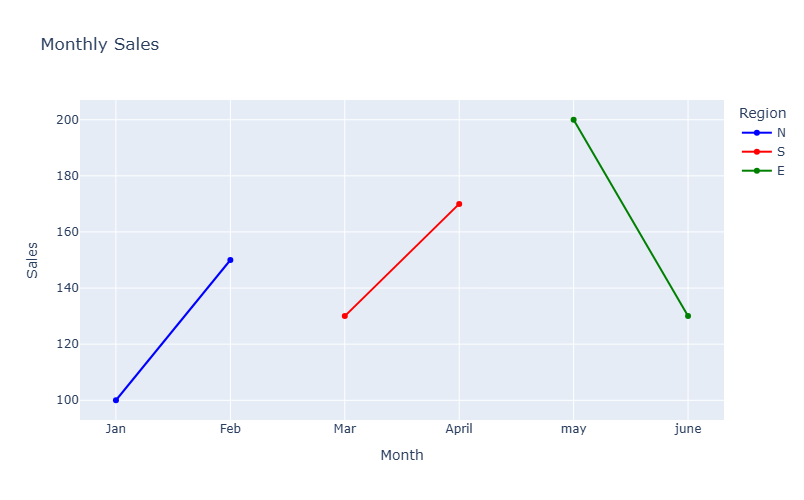

In [12]:
data={'Month':['Jan','Feb','Mar','April','may','june'],
      'Sales':[100,150,130,170,200,130],
      'Region':['N','N','S','S','E','E'],
      'profit':[10,20,30,40,50,60]
     }
df=pd.DataFrame(data)
fig=px.line(df,x='Month',y='Sales',markers=True,
            title='Monthly Sales',
            color='Region',
            width=800,
            height=500,
            color_discrete_sequence=['blue','red','green'],  # Added comma here
           hover_data = ["profit"]
           )
            
fig.show()

# Histogram

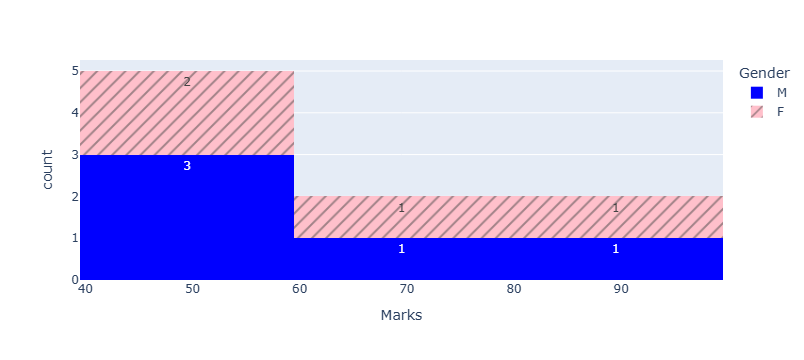

In [21]:
data = {"Marks":[40,45,50,55,49,70,75,80,85],
        "Gender":['M','F','M','F','M','F','M','F','M']
       }

df = pd.DataFrame(data)
fig = px.histogram(
    df,
    x = 'Marks',
    nbins=4,
    color='Gender',
    histfunc="count",
    pattern_shape="Gender",
    text_auto=True,
    color_discrete_map={'M':'Blue','F':'Pink'},
    color_discrete_sequence=['blue','pink']
)
fig.show()

# pie chart 

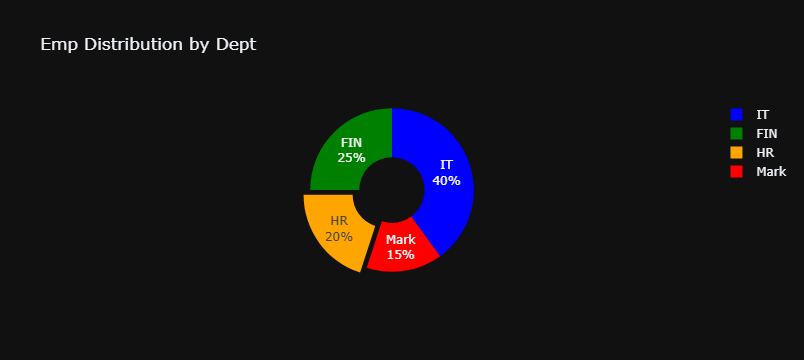

In [25]:
data = {'dept':['IT','HR','FIN','Mark'],
       "Emp":[40,20,25,15]
       }
df = pd.DataFrame(data)
fig = px.pie(df,values="Emp",names="dept",color_discrete_sequence=['blue','green','orange','red'],hole=0.4,template="plotly_dark",title="Emp Distribution by Dept")
fig.update_traces(textinfo = "percent+label", textposition ="inside",pull=[0,0.1,0,0])
fig.show()

# Unit - 3: 

In [27]:
romm_l = [18,20,10,12]
room_b = [20,20,10,11]
room_type = ['Big','Big','Normal','Normal']
data = pd.DataFrame({'Length':romm_l ,'Breadth':room_b,'Type':room_type})
data['Area'] = data['Length'] * data['Breadth']
print(data)

   Length  Breadth    Type  Area
0      18       20     Big   360
1      20       20     Big   400
2      10       10  Normal   100
3      12       11  Normal   132


In [28]:
data['Addition'] = data['Length'] + data['Breadth']
print(data)

   Length  Breadth    Type  Area  Addition
0      18       20     Big   360        38
1      20       20     Big   400        40
2      10       10  Normal   100        20
3      12       11  Normal   132        23


In [29]:
data['10/Length'] = 10/data['Length']
print(data)

   Length  Breadth    Type  Area  Addition  10/Length
0      18       20     Big   360        38   0.555556
1      20       20     Big   400        40   0.500000
2      10       10  Normal   100        20   1.000000
3      12       11  Normal   132        23   0.833333


In [42]:
import pandas as pd
df = pd.read_csv("python-2_lab/diabetes_unclean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1009 non-null   int64  
 1   No_Pation  1009 non-null   int64  
 2   Gender     1009 non-null   object 
 3   AGE        1008 non-null   float64
 4   Urea       1008 non-null   float64
 5   Cr         1007 non-null   float64
 6   HbA1c      1006 non-null   float64
 7   Chol       1007 non-null   float64
 8   TG         1007 non-null   float64
 9   HDL        1008 non-null   float64
 10  LDL        1007 non-null   float64
 11  VLDL       1008 non-null   float64
 12  BMI        1009 non-null   float64
 13  CLASS      1009 non-null   object 
dtypes: float64(10), int64(2), object(2)
memory usage: 110.5+ KB


In [43]:
df = pd.get_dummies(data= df,drop_first=False)
df

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Gender_F,Gender_M,Gender_f,CLASS_N,CLASS_N,CLASS_P,CLASS_Y,CLASS_Y
0,502,17975,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,False,True,False,False,False,False
1,735,34221,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,False,True,False,True,False,False,False,False
2,420,47975,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,False,True,False,False,False,False
3,680,87656,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,False,True,False,False,False,False
4,504,34223,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,191,454316,55.0,NaN,62.0,6.8,5.3,2.0,1.0,3.5,0.9,30.1,False,True,False,False,False,False,False,True
1005,192,454316,55.0,4.8,88.0,NaN,5.7,4.0,0.9,3.3,1.8,30.0,False,True,False,False,False,False,False,True
1006,193,454316,62.0,6.3,82.0,6.7,5.3,2.0,1.0,3.5,NaN,30.1,False,True,False,False,False,False,False,True
1007,194,454316,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,True,False,False,False,False,False,False,True


In [44]:
df = pd.get_dummies(data= df,drop_first=False)
df

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Gender_F,Gender_M,Gender_f,CLASS_N,CLASS_N,CLASS_P,CLASS_Y,CLASS_Y
0,502,17975,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,False,True,False,False,False,False
1,735,34221,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,False,True,False,True,False,False,False,False
2,420,47975,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,False,True,False,False,False,False
3,680,87656,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,False,True,False,False,False,False
4,504,34223,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,191,454316,55.0,NaN,62.0,6.8,5.3,2.0,1.0,3.5,0.9,30.1,False,True,False,False,False,False,False,True
1005,192,454316,55.0,4.8,88.0,NaN,5.7,4.0,0.9,3.3,1.8,30.0,False,True,False,False,False,False,False,True
1006,193,454316,62.0,6.3,82.0,6.7,5.3,2.0,1.0,3.5,NaN,30.1,False,True,False,False,False,False,False,True
1007,194,454316,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,True,False,False,False,False,False,False,True


In [48]:
import numpy as np
import pandas as pd

area = [4720, 2430, 4368, 6142]
price = [120000, 119000, 280000, 300000]
data = pd.DataFrame({'Area': area, 'Price': price})

# Example of using np.where with properly defined condition, x, and y
# For example, creating a new column that categorizes prices as 'High' or 'Low'
data['Price_Category'] = np.where(data['Price'] > 200000, 'High', 'Low')

print(data)

# Fixed: Changed 'price' to 'Price' to match the actual column name
data['Price_Category'] = np.where(data['Price'] > 200000, 'High', 'Low')

   Area   Price Price_Category
0  4720  120000            Low
1  2430  119000            Low
2  4368  280000           High
3  6142  300000           High
